In [43]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict

## Load Data

In [5]:

iris_data = load_iris()

## Explore data

In [6]:
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
print(iris_data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [8]:
iris_data['data']

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
iris_data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
iris_data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [11]:
iris_data['feature_names']  

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## View data

In [12]:
df = pd.DataFrame(data=iris_data['data'], columns=iris_data['feature_names'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
#include target and target names in the dataframe
df['target'] = iris_data['target']
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


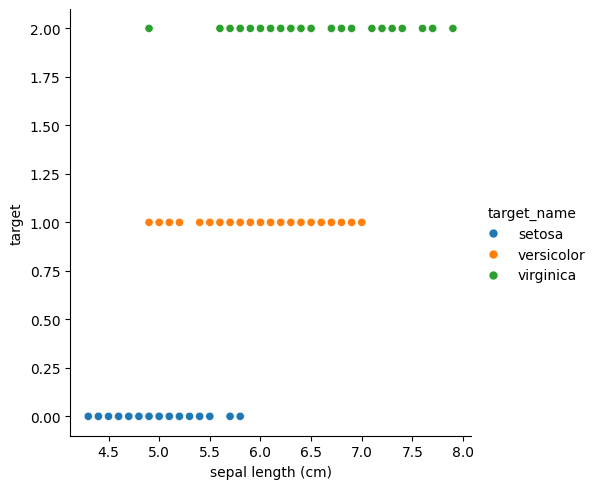

In [14]:
sns.relplot(data= df , x='sepal length (cm)', y='target', hue='target_name')

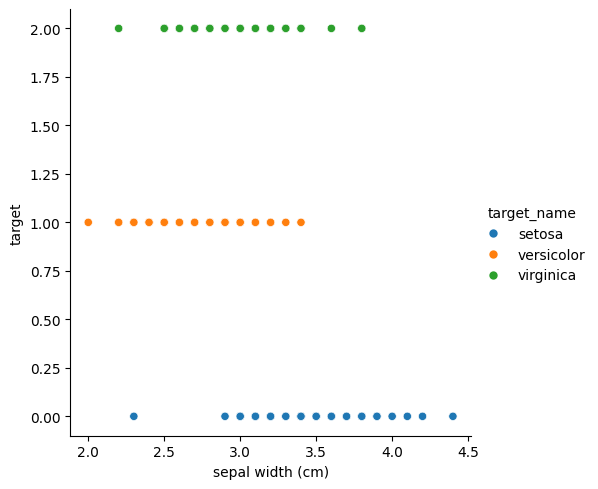

In [15]:
sns.relplot(data= df , x='sepal width (cm)', y='target', hue='target_name')

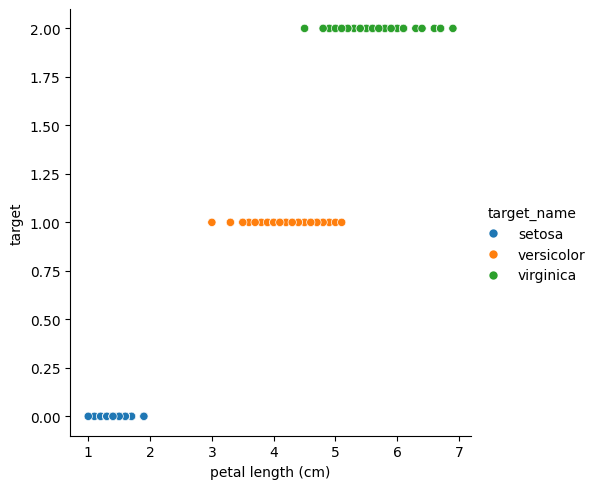

In [16]:
sns.relplot(data= df , x='petal length (cm)', y='target', hue='target_name')

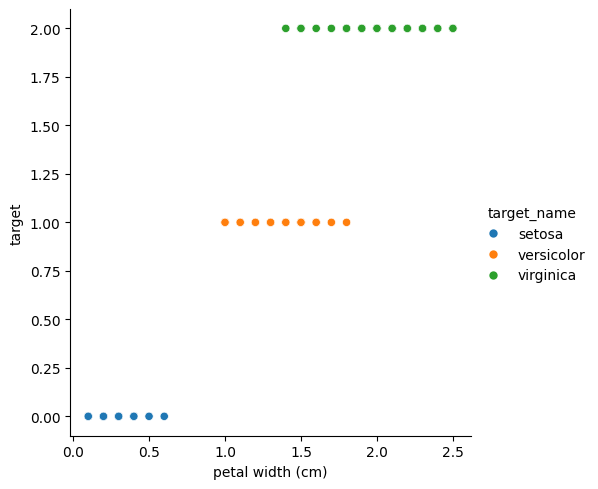

In [17]:
sns.relplot(data= df , x='petal width (cm)', y='target', hue='target_name')

In [18]:
# add exploratory features
df['petal L/W (cm)'] = df['petal length (cm)'] / df['petal width (cm)']
df['sepal L/W (cm)'] = df['sepal length (cm)'] / df['sepal width (cm)']
df['sepal/petal length(cm)'] = df['sepal length (cm)'] / df['petal length (cm)']
df['sepal/petal width (cm)'] = df['sepal width (cm)'] / df['petal width (cm)']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,petal L/W (cm),sepal L/W (cm),sepal/petal length(cm),sepal/petal width (cm)
0,5.1,3.5,1.4,0.2,0,setosa,7.0,1.457143,3.642857,17.5
1,4.9,3.0,1.4,0.2,0,setosa,7.0,1.633333,3.500000,15.0
2,4.7,3.2,1.3,0.2,0,setosa,6.5,1.468750,3.615385,16.0
3,4.6,3.1,1.5,0.2,0,setosa,7.5,1.483871,3.066667,15.5
4,5.0,3.6,1.4,0.2,0,setosa,7.0,1.388889,3.571429,18.0


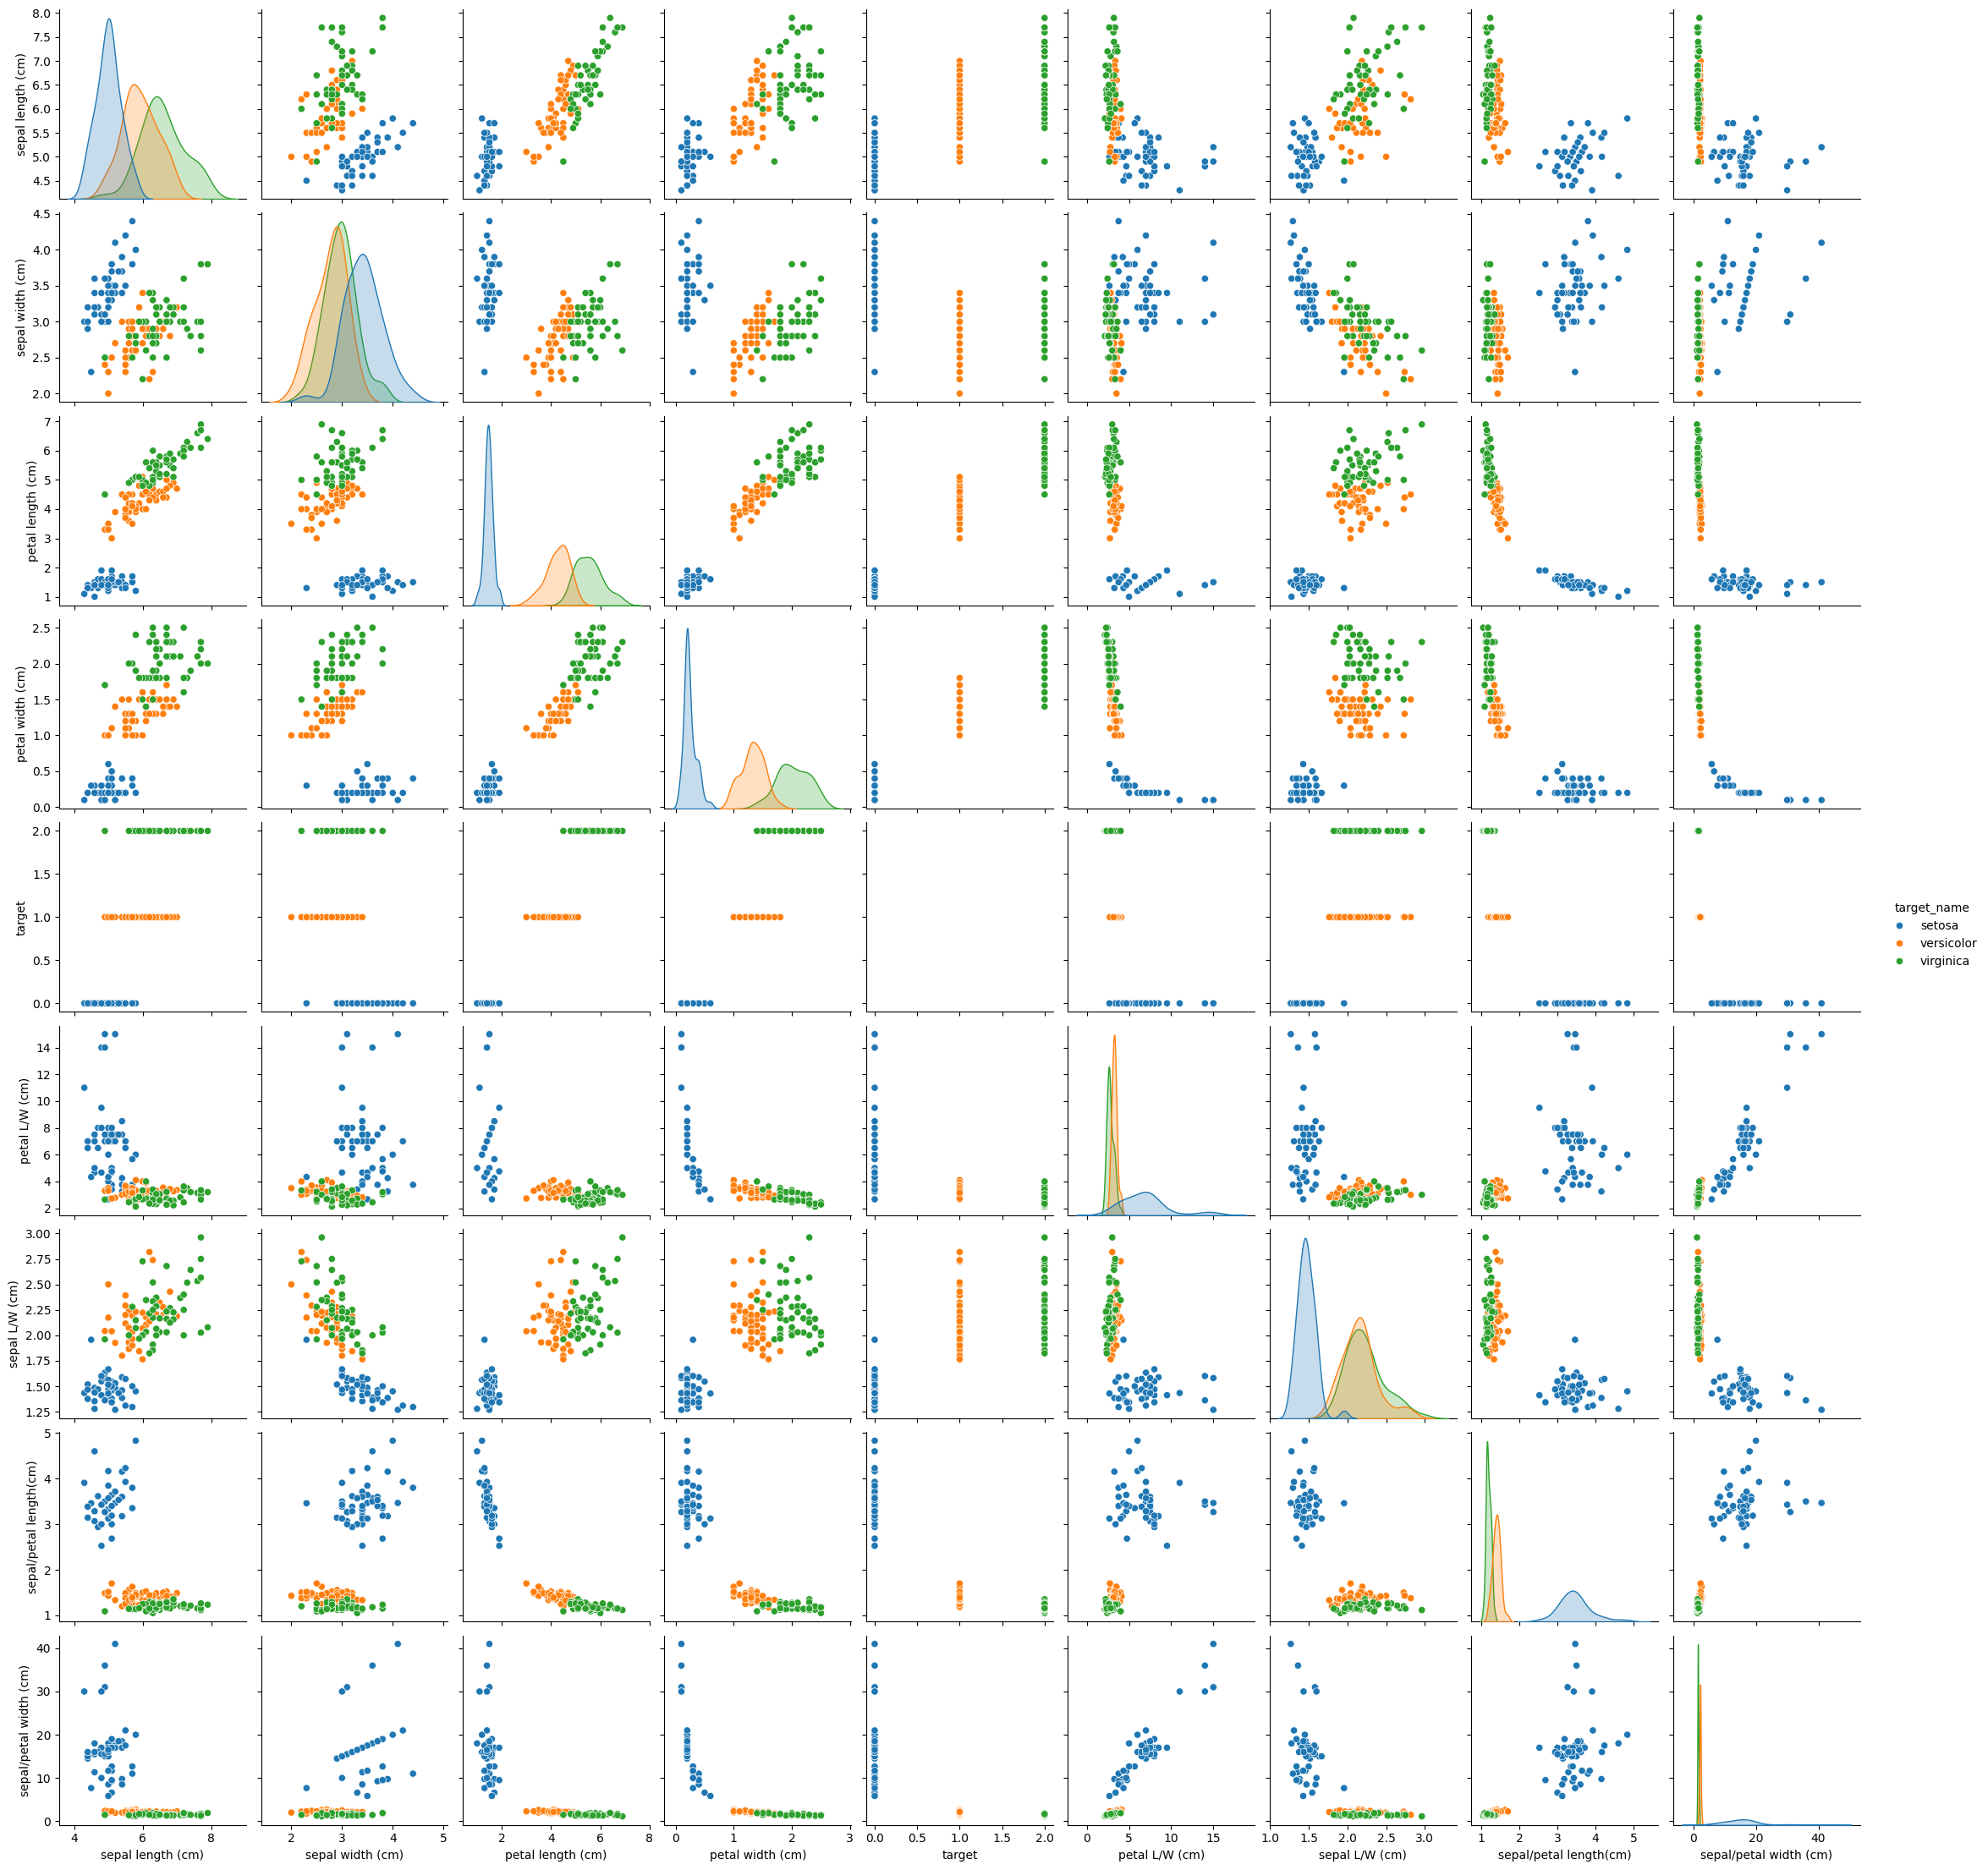

In [19]:
sns.pairplot(df, hue='target_name')

## Train test split


In [ ]:
X = df.drop(columns=['target', 'target_name']).values
y = df['target'].values

X2, X_test, y2, y_test = train_test_split(X,y,test_size=0.25)

X_train, X_val, y_train, y_val = train_test_split(X2, y2, test_size=0.25)

## Models

### Log regression

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_val, y_val)

0.9642857142857143

In [ ]:
#explicit score calculation

y_pred = model.predict(X_val)
results = y_pred == y_val
np.mean(results)


np.float64(0.9642857142857143)

In [49]:
#using cross validation
model1 = LogisticRegression(max_iter=200)
scores = cross_val_score(model1, X2, y2, cv=5)
scores.mean()


np.float64(0.9822134387351777)

In [53]:
#using explicit score calculation with cross val predict to find errors
y_pred_cv = cross_val_predict(model1, X2, y2, cv=5)
results_cv_mask = y_pred_cv == y2
X2[~results_cv_mask]  #misclassified samples

array([[6.3       , 2.5       , 4.9       , 1.5       , 3.26666667,
        2.52      , 1.28571429, 1.66666667],
       [6.3       , 2.8       , 5.1       , 1.5       , 3.4       ,
        2.25      , 1.23529412, 1.86666667]])